# ML Prediction Competition Project

Response variable: PERCENT_PROFICIENT
=> percentage of students at each school who score in the “Proficient” range (i.e., at or above grade level) on a wide battery of standardized tests during the 2024 testing period.
=> From TRAINING_SET

What is defined as proficient??

New York administers two primary sets of standardized exams:

Grade 3-8 Exams:
-English Language Arts (“ELA”) given every year
-Mathematics given every year
-Science, typically given only in grade 5 and grade 8

Regents Exams for high school students

The Regents exams cover a broader variety of topics and, historically, have been a graduation requirement in NYS. For each exam, a “proficiency” level is determined: e.g., if a exam gives scores from “1” to “4”, levels “3” and “4” may be considered “proficient”. Your task is to predict the fraction of students who achieve proficiency.

The organization of public schools in New York State 

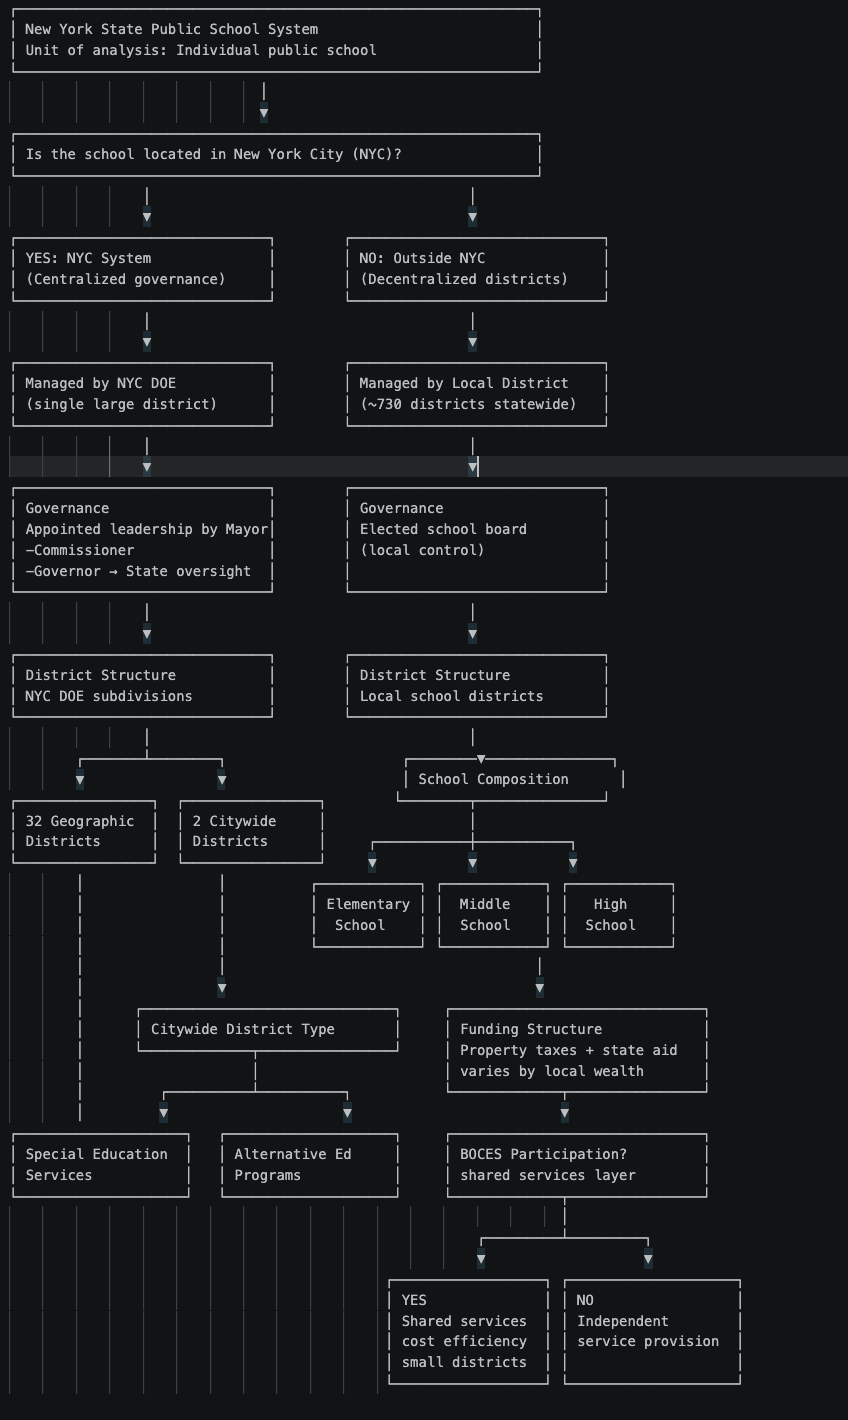

In [72]:
import pandas as pd

TRAINING_SET = pd.read_csv(
   "https://michael-weylandt.com/STA9890/competition_data/scores_training.csv"
)

TEST_SET = pd.read_csv(
   "https://michael-weylandt.com/STA9890/competition_data/scores_test.csv"
)

MEAN_PROFICIENCY =  TRAINING_SET["PERCENT_PROFICIENT"].mean()

TEST_SET[["ASSESSMENT_ID"]].\
    assign(PERCENT_PROFICIENT=MEAN_PROFICIENCY).\
    to_csv("intercept_model_for_kaggle_py.csv", 
           index=False)

SCHOOLS_INFO = pd.read_csv(
    "https://michael-weylandt.com/STA9890/competition_data/school_covariates.csv"
)

COUNTY_AVERAGES = TRAINING_SET.\
    merge(SCHOOLS_INFO, on="SCHOOL", how="inner").\
    groupby(["COUNTY", "SUBGROUP_NAME", "ASSESSMENT_NAME"], 
            as_index=False).\
    agg(PERCENT_PROFICIENT=("PERCENT_PROFICIENT", "mean"))


TEST_PREDICTIONS = TEST_SET.\
    merge(SCHOOLS_INFO, on="SCHOOL", how="inner").\
    loc[:, ["ASSESSMENT_ID", "ASSESSMENT_NAME", "COUNTY", "SUBGROUP_NAME"]].\
    merge(COUNTY_AVERAGES, on=["COUNTY", "SUBGROUP_NAME", "ASSESSMENT_NAME"], how="left")

TEST_PREDICTIONS["PERCENT_PROFICIENT"] = TEST_PREDICTIONS["PERCENT_PROFICIENT"].fillna(MEAN_PROFICIENCY)

TEST_PREDICTIONS[["ASSESSMENT_ID", "PERCENT_PROFICIENT"]].to_csv(
    "county_averages_model_for_kaggle_py.csv",
    index=False
)

In [73]:
%pip install seaborn

# Core setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


Note: you may need to restart the kernel to use updated packages.


In [74]:
SCHOOLS_INFO.head()



,SCHOOL,DISTRICT,COUNTY,DISTRICT_TYPE,REGION,ATTENDANCE_RATE,LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,MATHEMATICS_AVERAGE_CLASS_SIZE,SCIENCE_AVERAGE_CLASS_SIZE,HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE,GRADE_1_AVERAGE_CLASS_SIZE,GRADE_2_AVERAGE_CLASS_SIZE,KINDERGARTEN_AVERAGE_CLASS_SIZE,PERCENT_FREE_LUNCH,PERCENT_REDUCED_LUNCH,NUMBER_OF_TEACHERS,NUMBER_OF_COUNSELORS,NUMBER_OF_SOCIAL_WORKERS,TEACHER_TURNOVER_RATE,PERCENT_OF_STUDENTS_SUSPENDED,N_PUPILS,FEDERAL_FUNDING_PER_PUPIL,LOCAL_FUNDING_PER_PUPIL,PRE_K,K,GRADE_01,GRADE_02,GRADE_03,GRADE_04,GRADE_05,GRADE_06,GRADE_07,GRADE_08,GRADE_09,GRADE_10,GRADE_11,GRADE_12,PERCENT_MALE,PERCENT_FEMALE,PERCENT_ENGLISH_LANGUAGE_LEANERS,PERCENT_AMERICAN_INDIAN,PERCENT_BLACK,PERCENT_ASIAN,PERCENT_HISPANIC,PERCENT_WHITE,PERCENT_MULTIRACIAL,PERCENT_WITH_DISABILITIES,PERCENT_ECONOMICALLY_DISADVANTAGED,PERCENT_MIGRANT,PERCENT_HOMELESS,PERCENT_IN_FOSTER_CARE,PERCENT_PARENT_ARMED_FORCES
0,200cb9f4,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",95.0,23.000000,23.000000,21.0,NaN,NaN,NaN,NaN,36.0,0.0,29.0,0.0,1.0,NaN,0.0,324.0,4087.0,30054.0,32.0,51.0,48.0,49.0,49.0,47.0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,48.0,5.0,0.0,22.0,13.0,11.0,43.0,11.0,10.0,36.0,0.0,1.0,0.0,0.0
1,fe6c45ae,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",92.0,12.000000,12.333333,12.0,NaN,NaN,NaN,NaN,76.0,0.0,55.0,0.0,1.0,NaN,3.0,347.0,4447.0,30340.0,0.0,55.0,68.0,57.0,45.0,63.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,46.0,25.0,0.0,36.0,15.0,22.0,19.0,8.0,15.0,76.0,0.0,4.0,2.0,0.0
2,edd71301,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",91.0,11.666667,11.666667,11.0,NaN,NaN,NaN,NaN,84.0,0.0,49.0,0.0,1.0,NaN,1.0,311.0,3529.0,24776.0,20.0,51.0,49.0,52.0,52.0,45.0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,30.0,1.0,32.0,17.0,35.0,9.0,7.0,5.0,84.0,0.0,3.0,0.0,0.0
3,f3fc11ad,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",94.0,13.000000,13.000000,15.0,NaN,NaN,NaN,NaN,48.0,0.0,61.0,0.0,2.0,NaN,1.0,459.0,3973.0,30560.0,0.0,72.0,87.0,85.0,63.0,79.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,48.0,13.0,0.0,23.0,12.0,15.0,38.0,11.0,14.0,48.0,0.0,2.0,0.0,0.0
4,6f19e0a6,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",93.0,19.666667,19.666667,23.0,NaN,NaN,NaN,NaN,60.0,0.0,40.0,0.0,1.0,NaN,0.0,332.0,4919.0,36513.0,0.0,41.0,58.0,56.0,51.0,58.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44.0,56.0,5.0,0.0,43.0,10.0,17.0,18.0,11.0,13.0,60.0,0.0,6.0,0.0,0.0


In [75]:
TRAINING_SET.head()

,ASSESSMENT_ID,SCHOOL,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS,PERCENT_PROFICIENT
0,3b6deef53665,e037d064,Economically Disadvantaged,ELA4,130,38
1,962a3bfbfe84,5f633522,Male,ELA6,23,65
2,ffe086287b6e,2b76539e,All Students,Regents Algebra I,94,65
3,e6f80847409d,31289ced,All Students,MATH6,56,52
4,676cc6d81961,219db6e5,All Students,ELA8,134,46



A training set of 144921 are provided for you to build your models. The target variable for this data set is PERCENT_PROFICIENT, which ranges from 0 to 100. Scores here are reported for 4469 different schools (SCHOOL), 5 different subpopulations SUBGROUP_NAME, and 32different standardized assessments (ASSESSMENT_NAME). The SCHOOL column can be used to connect this data with the school-level covariates provided above.

We see here a rough bell curve in the overall population (with several artifacts resulting from the ‘discreteness’ of test scores), systematic underperformance of students from economically disadvantaged households, and a slight, but statistically significant, overperformance by female students.

The ASSESSMENT_ID column is a unique identifier used to identify a unique combination of (SCHOOL, SUBGROUP_NAME, ASSESSMENT_NAME). This will be used to organize your submissions on Kaggle, but is not of interest otherwise.

Finally, I also provide you with N_STUDENTS, the number of students who took each exam.

In [76]:
TEST_SET.head()

,ASSESSMENT_ID,SCHOOL,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS
0,8af5e0382a81,a49eed66,Not Economically Disadvantaged,Regents Phy Set/Earth Sci,5
1,e1591bf8db41,022f98d2,Economically Disadvantaged,MATH6,21
2,547ec44dcea6,255d51d5,All Students,MATH3,84
3,0e200399fc40,9442d8c4,Not Economically Disadvantaged,ELA7,7
4,c2c40438dac7,3f8e3d7a,Male,Regents US History&Gov't (Framework),44


ASSESSMENT_ID is basically a compressed label for a specific combination like:


-school


-subgroup


-assessment name

In [77]:
# Number of unique schools
schools_info_unique = SCHOOLS_INFO['SCHOOL'].nunique()
training_unique = TRAINING_SET['SCHOOL'].nunique()

print("no. of unique schools in schools info vs training data set\n",
    schools_info_unique, training_unique)

print("set difference",schools_info_unique-training_unique, "schools")

# Compare with total rows
print("\ncomparison\n",len(SCHOOLS_INFO), len(TRAINING_SET))

no. of unique schools in schools info vs training data set
 4754 4469
set difference 285 schools

comparison
 4754 144921


We will consider dropping these 285 schools later because they do not appear in the training dataset, meaning they provide no usable information for modeling or analysis tied to the training data.

The dataset dimensions confirm a one-to-many structure: SCHOOLS_INFO has 4754 rows (one per school), while TRAINING_SET has 144,921 rows, indicating multiple observations per school.

In [78]:
schools_info_set = set(SCHOOLS_INFO['SCHOOL'])
training_set = set(TRAINING_SET['SCHOOL'])

# Schools in training but not in info
missing_in_info = training_set - schools_info_set

# Schools in info but not in training
missing_in_training = schools_info_set - training_set

print(len(missing_in_info), len(missing_in_training))

0 285


In [79]:
SCHOOLS_INFO['SCHOOL'].is_unique

# Perfect clean 1-many join

True

Twe join below merges the two tables so that we can perform analysis smoothly

In [80]:
merged = TRAINING_SET.merge(SCHOOLS_INFO, on='SCHOOL', how='left')


In [81]:
merged[merged['SCHOOL'] == 'e037d064'].head() # Sample Sanity check for a school



,ASSESSMENT_ID,SCHOOL,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS,PERCENT_PROFICIENT,DISTRICT,COUNTY,DISTRICT_TYPE,REGION,ATTENDANCE_RATE,LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,MATHEMATICS_AVERAGE_CLASS_SIZE,SCIENCE_AVERAGE_CLASS_SIZE,HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE,GRADE_1_AVERAGE_CLASS_SIZE,GRADE_2_AVERAGE_CLASS_SIZE,KINDERGARTEN_AVERAGE_CLASS_SIZE,PERCENT_FREE_LUNCH,PERCENT_REDUCED_LUNCH,NUMBER_OF_TEACHERS,NUMBER_OF_COUNSELORS,NUMBER_OF_SOCIAL_WORKERS,TEACHER_TURNOVER_RATE,PERCENT_OF_STUDENTS_SUSPENDED,N_PUPILS,FEDERAL_FUNDING_PER_PUPIL,LOCAL_FUNDING_PER_PUPIL,PRE_K,K,GRADE_01,GRADE_02,GRADE_03,GRADE_04,GRADE_05,GRADE_06,GRADE_07,GRADE_08,GRADE_09,GRADE_10,GRADE_11,GRADE_12,PERCENT_MALE,PERCENT_FEMALE,PERCENT_ENGLISH_LANGUAGE_LEANERS,PERCENT_AMERICAN_INDIAN,PERCENT_BLACK,PERCENT_ASIAN,PERCENT_HISPANIC,PERCENT_WHITE,PERCENT_MULTIRACIAL,PERCENT_WITH_DISABILITIES,PERCENT_ECONOMICALLY_DISADVANTAGED,PERCENT_MIGRANT,PERCENT_HOMELESS,PERCENT_IN_FOSTER_CARE,PERCENT_PARENT_ARMED_FORCES
0,3b6deef53665,e037d064,Economically Disadvantaged,ELA4,130,38,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0
4085,00cb4d5ca301,e037d064,Female,MATH4,74,43,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0
15350,0db53b37a7a7,e037d064,All Students,ELA5,170,35,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0
15983,5658c0806cc9,e037d064,Not Economically Disadvantaged,MATH5,14,14,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0
18285,090e513f3e74,e037d064,Not Economically Disadvantaged,ELA5,14,14,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0


In [82]:
df = merged

# Assessment ID is redundant since the encoding also in test set
df = df.drop(columns=["ASSESSMENT_ID"]) 



In [83]:
# Basic structure
print(df.shape)
print(df.info())


(144921, 56)
<class 'pandas.DataFrame'>
RangeIndex: 144921 entries, 0 to 144920
Data columns (total 56 columns):
 #   Column                                               Non-Null Count   Dtype  
---  ------                                               --------------   -----  
 0   SCHOOL                                               144921 non-null  str    
 1   SUBGROUP_NAME                                        144921 non-null  str    
 2   ASSESSMENT_NAME                                      144921 non-null  str    
 3   N_STUDENTS                                           144921 non-null  int64  
 4   PERCENT_PROFICIENT                                   144921 non-null  int64  
 5   DISTRICT                                             144921 non-null  str    
 6   COUNTY                                               144921 non-null  str    
 7   DISTRICT_TYPE                                        144921 non-null  str    
 8   REGION                                              

In [84]:
# missingness analysis

missing = df.isna().sum().to_frame(name="missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df)) * 100

missing = missing.sort_values(by="missing_pct", ascending=False)

missing

,missing_count,missing_pct
TEACHER_TURNOVER_RATE,134136,92.558014
KINDERGARTEN_AVERAGE_CLASS_SIZE,103467,71.395450
GRADE_1_AVERAGE_CLASS_SIZE,102899,71.003512
GRADE_2_AVERAGE_CLASS_SIZE,102779,70.920709
HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE,89314,61.629439
SCIENCE_AVERAGE_CLASS_SIZE,8475,5.848014
LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,7156,4.937863
MATHEMATICS_AVERAGE_CLASS_SIZE,3795,2.618668
N_PUPILS,3646,2.515853
FEDERAL_FUNDING_PER_PUPIL,3646,2.515853


### Missingness Check

The following features have **60–93% missing values**:

* `TEACHER_TURNOVER_RATE`
* `KINDERGARTEN_AVERAGE_CLASS_SIZE`
* `GRADE_1_AVERAGE_CLASS_SIZE`
* `GRADE_2_AVERAGE_CLASS_SIZE`
* `HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE`

→ Dropped due to extreme sparsity


In [85]:
cols_to_drop = [
    "TEACHER_TURNOVER_RATE",
    "KINDERGARTEN_AVERAGE_CLASS_SIZE",
    "GRADE_1_AVERAGE_CLASS_SIZE",
    "GRADE_2_AVERAGE_CLASS_SIZE",
    "HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE"
]

df = df.drop(columns=cols_to_drop)


# missingness analysis

missing = df.isna().sum().to_frame(name="missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df)) * 100

missing = missing.sort_values(by="missing_pct", ascending=False)

missing.head()

,missing_count,missing_pct
SCIENCE_AVERAGE_CLASS_SIZE,8475,5.848014
LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,7156,4.937863
MATHEMATICS_AVERAGE_CLASS_SIZE,3795,2.618668
LOCAL_FUNDING_PER_PUPIL,3646,2.515853
FEDERAL_FUNDING_PER_PUPIL,3646,2.515853


In [88]:
# Basic structure recheck
print(df.shape)
print(df.info())

(144921, 51)
<class 'pandas.DataFrame'>
RangeIndex: 144921 entries, 0 to 144920
Data columns (total 51 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   SCHOOL                              144921 non-null  str    
 1   SUBGROUP_NAME                       144921 non-null  str    
 2   ASSESSMENT_NAME                     144921 non-null  str    
 3   N_STUDENTS                          144921 non-null  int64  
 4   PERCENT_PROFICIENT                  144921 non-null  int64  
 5   DISTRICT                            144921 non-null  str    
 6   COUNTY                              144921 non-null  str    
 7   DISTRICT_TYPE                       144921 non-null  str    
 8   REGION                              144921 non-null  str    
 9   ATTENDANCE_RATE                     141885 non-null  float64
 10  LANGUAGE_ARTS_AVERAGE_CLASS_SIZE    137765 non-null  float64
 11  MATHEMATICS_AVERAGE_CLAS

In [98]:
# More basic structure sanity check

print(df.describe(include="all").T)
df.sample(5)

                                       count unique            top   freq          mean          std   min        25%  \
SCHOOL                                144921   4469       6f557320    100           NaN          NaN   NaN        NaN   
SUBGROUP_NAME                         144921      5   All Students  36711           NaN          NaN   NaN        NaN   
ASSESSMENT_NAME                       144921     32           ELA3   8392           NaN          NaN   NaN        NaN   
N_STUDENTS                          144921.0    NaN            NaN    NaN     57.664748    67.211682   5.0       21.0   
PERCENT_PROFICIENT                  144921.0    NaN            NaN    NaN     54.183521    26.429925   0.0       33.0   
DISTRICT                              144921    710       03759bb1  13986           NaN          NaN   NaN        NaN   
COUNTY                                144921     62       062c154c  17112           NaN          NaN   NaN        NaN   
DISTRICT_TYPE                   

,SCHOOL,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS,PERCENT_PROFICIENT,DISTRICT,COUNTY,DISTRICT_TYPE,REGION,ATTENDANCE_RATE,LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,MATHEMATICS_AVERAGE_CLASS_SIZE,SCIENCE_AVERAGE_CLASS_SIZE,PERCENT_FREE_LUNCH,PERCENT_REDUCED_LUNCH,NUMBER_OF_TEACHERS,NUMBER_OF_COUNSELORS,NUMBER_OF_SOCIAL_WORKERS,PERCENT_OF_STUDENTS_SUSPENDED,N_PUPILS,FEDERAL_FUNDING_PER_PUPIL,LOCAL_FUNDING_PER_PUPIL,PRE_K,K,GRADE_01,GRADE_02,GRADE_03,GRADE_04,GRADE_05,GRADE_06,GRADE_07,GRADE_08,GRADE_09,GRADE_10,GRADE_11,GRADE_12,PERCENT_MALE,PERCENT_FEMALE,PERCENT_ENGLISH_LANGUAGE_LEANERS,PERCENT_AMERICAN_INDIAN,PERCENT_BLACK,PERCENT_ASIAN,PERCENT_HISPANIC,PERCENT_WHITE,PERCENT_MULTIRACIAL,PERCENT_WITH_DISABILITIES,PERCENT_ECONOMICALLY_DISADVANTAGED,PERCENT_MIGRANT,PERCENT_HOMELESS,PERCENT_IN_FOSTER_CARE,PERCENT_PARENT_ARMED_FORCES
65468,f14c8f54,Not Economically Disadvantaged,Regents Common Core Algebra I,13,46,90308148,26ea5314,Low Need,Hudson Valley,97.0,21.000000,13.000000,22.000000,7.0,0.0,111.0,9.0,0.0,2.0,1140.0,194.0,37990.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,322.0,273.0,287.0,52.0,48.0,0.0,0.0,1.0,16.0,8.0,70.0,5.0,12.0,7.0,0.0,0.0,0.0,0.0
116794,314dd246,Male,Regents Phy Set/Earth Sci,24,96,aa39ffd4,3394bc12,Average Need,Western New York,95.0,19.250000,19.600000,21.333333,24.0,1.0,64.0,3.0,1.0,2.0,603.0,853.0,24170.0,0.0,0.0,0.0,0.0,0.0,0.0,151.0,154.0,144.0,142.0,0.0,0.0,0.0,0.0,48.0,52.0,5.0,0.0,4.0,12.0,4.0,74.0,5.0,17.0,26.0,0.0,1.0,0.0,1.0
5895,b6c17916,Not Economically Disadvantaged,ELA5,26,38,a6bd5b8b,9d7af256,Average Need,Long Island,92.0,17.333333,17.333333,17.000000,49.0,3.0,56.0,0.0,1.0,1.0,631.0,1901.0,23126.0,28.0,101.0,102.0,108.0,105.0,101.0,86.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0,49.0,20.0,0.0,10.0,4.0,54.0,28.0,4.0,12.0,52.0,0.0,2.0,0.0,0.0
106875,c298f05a,Female,Regents Phy Set/Earth Sci,14,100,b49e2ea9,062c154c,NYC,New York City,92.0,20.000000,18.000000,20.666667,73.0,6.0,34.0,2.0,1.0,1.0,357.0,5287.0,21288.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,91.0,96.0,84.0,86.0,46.0,54.0,1.0,1.0,69.0,7.0,15.0,4.0,4.0,14.0,80.0,0.0,4.0,1.0,0.0
113439,0be6ec5f,Male,MATH4,24,42,a5fd67fc,4ea4cbc6,Average Need,Central New York,92.0,18.000000,18.000000,NaN,55.0,3.0,21.0,0.0,1.0,3.0,241.0,2442.0,23657.0,32.0,35.0,34.0,52.0,38.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0,49.0,0.0,0.0,1.0,0.0,2.0,93.0,3.0,19.0,65.0,0.0,6.0,3.0,0.0


In [101]:
# Column names and data types
print(df.columns)
len(df.columns)


Index(['SCHOOL', 'SUBGROUP_NAME', 'ASSESSMENT_NAME', 'N_STUDENTS', 'PERCENT_PROFICIENT', 'DISTRICT', 'COUNTY',
       'DISTRICT_TYPE', 'REGION', 'ATTENDANCE_RATE', 'LANGUAGE_ARTS_AVERAGE_CLASS_SIZE',
       'MATHEMATICS_AVERAGE_CLASS_SIZE', 'SCIENCE_AVERAGE_CLASS_SIZE', 'PERCENT_FREE_LUNCH', 'PERCENT_REDUCED_LUNCH',
       'NUMBER_OF_TEACHERS', 'NUMBER_OF_COUNSELORS', 'NUMBER_OF_SOCIAL_WORKERS', 'PERCENT_OF_STUDENTS_SUSPENDED',
       'N_PUPILS', 'FEDERAL_FUNDING_PER_PUPIL', 'LOCAL_FUNDING_PER_PUPIL', 'PRE_K', 'K', 'GRADE_01', 'GRADE_02',
       'GRADE_03', 'GRADE_04', 'GRADE_05', 'GRADE_06', 'GRADE_07', 'GRADE_08', 'GRADE_09', 'GRADE_10', 'GRADE_11',
       'GRADE_12', 'PERCENT_MALE', 'PERCENT_FEMALE', 'PERCENT_ENGLISH_LANGUAGE_LEANERS', 'PERCENT_AMERICAN_INDIAN',
       'PERCENT_BLACK', 'PERCENT_ASIAN', 'PERCENT_HISPANIC', 'PERCENT_WHITE', 'PERCENT_MULTIRACIAL',
       'PERCENT_WITH_DISABILITIES', 'PERCENT_ECONOMICALLY_DISADVANTAGED', 'PERCENT_MIGRANT', 'PERCENT_HOMELESS',
       'PE

51

### Column analysis

51-response = 50 covariates total

In [ ]:
print(df.nunique().sort_values())

SUBGROUP_NAME                            5
DISTRICT_TYPE                            7
PERCENT_IN_FOSTER_CARE                   8
REGION                                  10
PERCENT_MIGRANT                         11
NUMBER_OF_SOCIAL_WORKERS                14
PERCENT_REDUCED_LUNCH                   20
NUMBER_OF_COUNSELORS                    21
PERCENT_PARENT_ARMED_FORCES             23
PERCENT_MULTIRACIAL                     24
ASSESSMENT_NAME                         32
PERCENT_AMERICAN_INDIAN                 34
PERCENT_OF_STUDENTS_SUSPENDED           43
ATTENDANCE_RATE                         58
PERCENT_WITH_DISABILITIES               61
COUNTY                                  62
PERCENT_HOMELESS                        62
PERCENT_FEMALE                          68
PERCENT_MALE                            69
PERCENT_ENGLISH_LANGUAGE_LEANERS        86
PERCENT_ASIAN                           89
PERCENT_BLACK                           92
PERCENT_WHITE                          101
PERCENT_HIS

In [107]:
# Cardinality analysis of categorical variables
cat_cols = df.select_dtypes(include="str").columns

df[cat_cols].nunique().sort_values()

SUBGROUP_NAME         5
DISTRICT_TYPE         7
REGION               10
ASSESSMENT_NAME      32
COUNTY               62
DISTRICT            710
SCHOOL             4469
dtype: int64

### Categorical Cardinality

* **Low cardinality:**
  `SUBGROUP_NAME` (5), `DISTRICT_TYPE` (7), `REGION` (10)

* **Moderate:**
  `ASSESSMENT_NAME` (32), `COUNTY` (62)

* **High cardinality:**
  `DISTRICT` (710), `SCHOOL` (4469)

### Notes

* Low → suitable for one-hot encoding
* High → may require alternative handling (or exclusion)
